# Climate Change Portfolio Post

Climate change is impacting the way people live around the world. Higher highs, lower lows, storms, and smoke – we’re all feeling the
effects of climate change. Here, we look at trends in temperature over time along the San Pedro River in Arizona.

## Wrangle data

### Load Python packages

In [30]:
### import libraries
import earthpy ### manage local data
import holoviews as hv ### save interactive plots
import hvplot.pandas ### make interactive plots
import pandas as pd ### analyze and manipulate data

### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt

### common statistical plots for tabular data
import seaborn as sns

### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

### Download the data

I've downloaded some climate data from NCEI for the Muleshoe Ranch Station in Southeast Arizona in CSV format (https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USR0000AMUL/detail). I'm interested in this area because some of my research focuses on assessing floodplain organic carbon stocks along the San Pedro River, AZ, which this station is located right next to. 

Southeast Arizona has an arid climate and has been experiencing an extended drought. I'm interested in seeing whether there is a significant trend in temperature over the last few decades in this region near one of my study sites.

In the field, we saw that many riparian areas that were altered by human activities had depleted ground water levels, reduced presence of large native vegetation, and in some places, the channel had completely dried up. I would hypothesize that increased mean annual temperatures may have exacerbated some of these changes that we observed.

In [31]:
### import data as df
arizona_df = pd.read_csv('muleshoe_ranch_climate_data.csv',

    ### Tell python which column to use as the index
    index_col='DATE',

    ### Tell python to treat the DATE as a date
    parse_dates=True,

    ### Designate NaNs as missing data
    na_values=["NaN"]
)

In [32]:
### check that data was imported into a pandas DataFrame
type(arizona_df)

pandas.core.frame.DataFrame

### Clean up the `DataFrame`

In [33]:
### create new df that only includes temperature column
az_temp_df = arizona_df[['TAVG']]
az_temp_df

,TAVG
DATE,
1988-04-05,70
1988-04-06,67
1988-04-28,59
1988-04-29,60
1988-04-30,69
...,...
2026-09-13,77
2026-09-14,76
2026-09-15,75


### Convert the units

Here we'll make sure we're using the right units by converting from F to C.

In [34]:
### rename temperature column to include units
temp_units_df = az_temp_df.rename(columns={
    'TAVG': 'temp_f',
})

We'll do this by creating a function for the unit conversion.

In [35]:
### create function to convert units from f to c
def convert_f_to_c(temperature_f):
    """Convert temperature to Celsius"""
    return (temperature_f - 32)*5/9

### convert temp data from f to c
temp_units_df['temp_c'] = (
    temp_units_df['temp_f'].apply(convert_f_to_c))


## Plot the temperature data

Here we'll plot all of the daily temperature data. This will show us whether there are any gaps in the data or any measurements that look incorrect. 

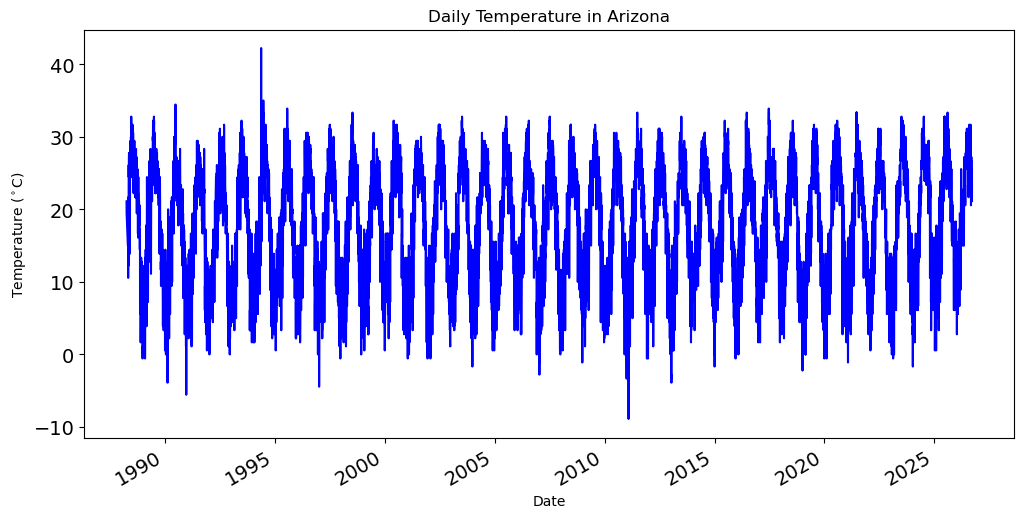

In [36]:
### plot without the legend
no_legend = temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Arizona',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    ### increase fig size
    figsize = (12, 6),
    ### increase font size
    fontsize = 14,
    ### change color
    color = 'blue') 

no_legend.legend().remove()

### Clean up time series plots by resampling

Now we'll resample the data. This summarizes the data as an annual mean value, giving us one data point per year.

In [37]:
### resample to mean annual temps
annual_temp_df = (

    ### resample df
    temp_units_df

    ### sample annually
    .resample('YS')

    ### calculate mean
    .mean()
)

annual_temp_df

,temp_f,temp_c
DATE,,
1988-01-01,69.481781,20.823212
1989-01-01,64.482192,18.045662
1990-01-01,61.824658,16.569254
1991-01-01,61.413699,16.340944
1992-01-01,61.816940,16.564967
1993-01-01,63.158192,17.310107
1994-01-01,63.623626,17.568681
1995-01-01,63.522099,17.512277
1996-01-01,64.123288,17.846271


## Plot the annual data

<Axes: title={'center': 'Mean Annual Temperature in Arizona'}, xlabel='Year', ylabel='Temperature ($^\\circ$C)'>

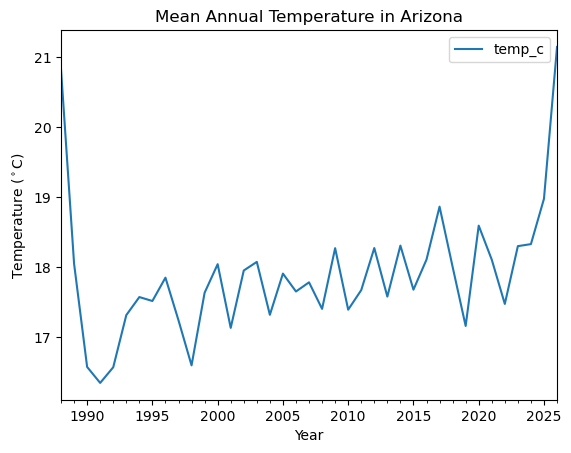

In [38]:
annual_temp_df.plot(y = 'temp_c',
                  title = 'Mean Annual Temperature in Arizona',
                  xlabel = 'Year',
                  ylabel = 'Temperature ($^\circ$C)')

>**Plot Interpretations**
>* We see that in the first and last year of data, the plotted mean annual temperature is extremely high compared to other years. This is caused by incomplete data. 2026 isn't over yet, and data from 1988 starts in April, so it would be a good idea to remove these years.
>* Mean annual temperatures are lower in the 1990s than they are in the 2020s. While this isn't a particularly long study period, this trend in 35+ years of data could be a result of climate change. It is difficult to say that conclusively without further analysis/looking at the data more closely.

## Make an interactive plot

In [39]:
### troubleshooting workaround for interactive plot
hvplot.extension("bokeh")

In [40]:
### plot the annual data interactively
annual_temp_plot = annual_temp_df.hvplot(
    y = 'temp_c',
    title = 'Mean Annual Temperature in SE Arizona',
    xlabel = 'Year',
    ylabel = 'Temperature (deg C)'
)

annual_temp_plot

:Curve   [DATE]   (temp_c)

>**Data Exploration**
>If we ignore years with incomplete data:
>* The minimum mean annual temperature is 16.341 degrees C in 1991
>* The maximum mean annual temperature is 18.974 degrees C in 2025

## Quantify how fast the climate is changing with a trend line

In [41]:
### subset data to only include temp in Celsius
annual_temp_c_df = annual_temp_df[['temp_c']]

### subset data to 1988-2025 because 2026 isn't a full year of data
complete_data_df = annual_temp_c_df.loc['1989':'2025']

In [42]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = complete_data_df.index.year.values.reshape(-1, 1)

### define dependent variable
dep_variable = complete_data_df

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: [0.03525516] degrees per year


### Plot your trend line

Trend lines are often used to help your audience understand and process
a time-series plot. In this case, we’ve chosen mean temperature values
rather than extremes, so we think OLS is an appropriate model to use to
show a trend.

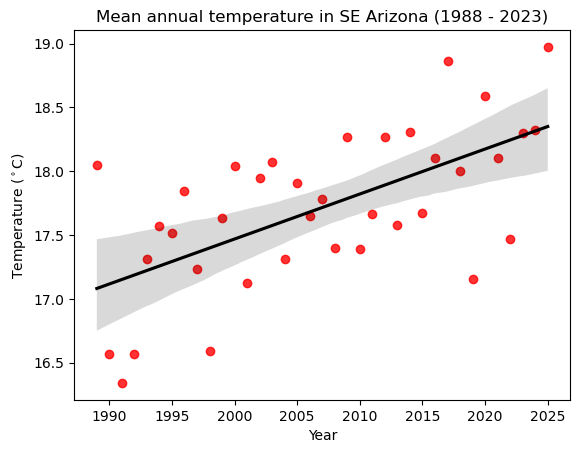

In [ ]:
### plot data
ax = sns.regplot(
    x = complete_data_df.index.year, 
    y = complete_data_df.temp_c,

    ### change the color of data points
    color = 'red',

    ### change the color of the trendline
    line_kws= {'color': 'black'}
)

### make labels
ax.set(
    title = 'Mean annual temperature in SE Arizona (1989 - 2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/climate-change/arizona-climate-trendline.jpeg')

### plot it
plt.show()

>*Mean annual temperatures in Boulder, CO have increased over the last century*

>In SE Arizona, mean annual temperatures have increased by 0.035 degrees C per year from 1989 to 2025. Temperatures are likely increasing as a result of climate change, although other environmental characteristics, like trends in sea surface temperatures, may also influence some of this rate of temperature change.